# AgriYield Prediction Pipeline (Optimized)
**Chống Overfitting và Leakage:** Đã loại bỏ hoàn toàn Production và loại bỏ các Outliers cực đoan trên tập Train để mô hình tổng quát hóa tốt hơn.
Sử dụng CatBoostRegressor xử lý trực tiếp phân loại (Categorical Features).

In [28]:
# !pip install catboost scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports OK')

Imports OK


In [29]:
train = pd.read_csv('Agri_Data_Train.csv')
test  = pd.read_csv('Agri_Data_Test.csv')

print(f'Train shape (raw): {train.shape}')
print(f'Test  shape (raw): {test.shape}')

# LOẠI BỎ NGOẠI LAI KHỎI TẬP TRAIN (Chống Overfitting)
# Các giá trị Yield > 30 là các điểm nhiễu cực đoan
train = train[train['Yield'] <= 30].reset_index(drop=True)
print(f'Train shape (sau khi xóa outliers Yield > 30): {train.shape}')

y_test_true = np.expm1(np.log1p(test['Yield']))
test_labels  = test['Yield'].copy()

Train shape (raw): (3342, 51)
Test  shape (raw): (836, 51)
Train shape (sau khi xóa outliers Yield > 30): (3323, 51)


In [30]:
DROP_COLS = [
    'Production',        # Phải xóa để chống Data Leakage
    'Harvest',           
    'Growth',            
    'Rain_Temp_Ratio',   
    'NDVI_Season_Range', 
]

for df in [train, test]:
    df.drop(columns=DROP_COLS, inplace=True, errors='ignore')

print(f'Remaining columns: {train.shape[1] - 1} features + Yield')

y_orig = train['Yield']
y_log = np.log1p(train['Yield'])   # skew=3.53 -> mandatory
X = train.drop(columns=['Yield'])

print(f'Target (log1p) — mean: {y_log.mean():.3f}, std: {y_log.std():.3f}, skew: {y_log.skew():.3f}')

Remaining columns: 45 features + Yield
Target (log1p) — mean: 1.324, std: 0.694, skew: 0.578


In [31]:
MONTH_MAP = {
    'January':1, 'February':2,  'March':3,    'April':4,
    'May':5,     'June':6,       'July':7,     'August':8,
    'September':9,'October':10, 'November':11,'December':12
}

for df in [X, test]:
    df['Transplant'] = df['Transplant'].map(MONTH_MAP).fillna(0).astype(int)

# Khai báo các biến Categorical cho CatBoost
CAT_COLS = ['District', 'Season', 'Crop Name', 'Transplant', 'pH_Suitability', 'Dominant_Soil_Texture', 'Water_Availability_Cat', 'Extreme_Heat_Risk']

for col in CAT_COLS:
    if col in X.columns:
        X[col] = X[col].fillna('Unknown').astype(str)
        test[col] = test[col].fillna('Unknown').astype(str)

In [32]:
# Define CatBoost Regressor
model = CatBoostRegressor(
    cat_features=CAT_COLS,
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    random_state=RANDOM_STATE,
    verbose=100
)

kf_eval = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Đang tiến hành 5-Fold Cross Validation...")
oof_log = np.zeros(len(X))

for tr_idx, val_idx in kf_eval.split(X):
    X_tr, y_tr = X.iloc[tr_idx], y_log.iloc[tr_idx]
    X_va, y_va = X.iloc[val_idx], y_log.iloc[val_idx]
    
    cb = model.copy()
    cb.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=100, verbose=0)
    oof_log[val_idx] = cb.predict(X_va)

oof_orig = np.expm1(oof_log)

Đang tiến hành 5-Fold Cross Validation...


In [33]:
def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(np.maximum(y_pred, 0)) - np.log1p(y_true))**2))

def metrics_dict(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    rl   = rmsle(np.array(y_true), np.array(y_pred))
    return dict(R2=r2, MAE=mae, MSE=mse, RMSE=rmse, RMSLE=rl)

m_oof_log = metrics_dict(y_log, oof_log)
m_oof_orig = metrics_dict(y_orig, oof_orig)

print("=" * 85)
print("  OOF 5-Fold Metrics on TRAIN")
print("=" * 85)
print(f"  [LOG SCALE]       R²={m_oof_log['R2']:>7.4f}  MAE={m_oof_log['MAE']:>7.4f}  RMSE={m_oof_log['RMSE']:>7.4f}")
print(f"  [ORIGINAL SCALE]  R²={m_oof_orig['R2']:>7.4f}  MAE={m_oof_orig['MAE']:>7.4f}  RMSE={m_oof_orig['RMSE']:>7.4f}")
print("=" * 85)

  OOF 5-Fold Metrics on TRAIN
  [LOG SCALE]       R²= 0.7021  MAE= 0.2583  RMSE= 0.3790
  [ORIGINAL SCALE]  R²= 0.5413  MAE= 1.4998  RMSE= 3.0166


In [35]:
print('Fitting full CatBoost ensemble on all training data...')
model.fit(X, y_log, verbose=200)
print('Training complete')

# Dự đoán trên TEST
test_features = test.drop(columns=['Yield'], errors='ignore')
y_pred_log = model.predict(test_features)
y_pred = np.expm1(y_pred_log)

m_test_log = metrics_dict(np.log1p(test_labels), y_pred_log)
m_test_orig = metrics_dict(test_labels, y_pred)

print("╔════════════════════════════════════════════════════════════════════════╗")
print("║              FINAL METRICS SUMMARY — CATBOOST ENSEMBLE                 ║")
print("╠══════════════════════╦══════════╦══════════╦═══════════════╦═══════════╣")
print("║  Set                 ║   R²     ║   MAE    ║     MSE       ║  RMSE     ║")
print("╠══════════════════════╬══════════╬══════════╬═══════════════╬═══════════╣")
for label, m in [('TEST (Log Scale)', m_test_log), ('TEST (Orig Scale)', m_test_orig)]:
    print(f"║  {label:<20}║ {m['R2']:>8.4f} ║ {m['MAE']:>8.4f} ║ {m['MSE']:>13.4f} ║ {m['RMSE']:>9.4f} ║")
print("╚══════════════════════╩══════════╩══════════╩═══════════════╩═══════════╝")

# Save
pd.DataFrame({'Predicted_Yield': y_pred, 'True_Yield': test_labels}).to_csv('predictions_v6.csv', index=False)
print(f"Saved predictions_v6.csv  ({len(y_pred)} rows)")

Fitting full CatBoost ensemble on all training data...
0:	learn: 0.6837509	total: 62ms	remaining: 1m 32s
200:	learn: 0.3459251	total: 17.9s	remaining: 1m 55s
400:	learn: 0.2903199	total: 37.3s	remaining: 1m 42s
600:	learn: 0.2491161	total: 51.8s	remaining: 1m 17s
800:	learn: 0.2163008	total: 1m 10s	remaining: 1m 1s
1000:	learn: 0.1915951	total: 1m 37s	remaining: 48.4s
1200:	learn: 0.1732608	total: 1m 58s	remaining: 29.5s
1400:	learn: 0.1558753	total: 2m 18s	remaining: 9.78s
1499:	learn: 0.1479986	total: 2m 29s	remaining: 0us
Training complete
╔════════════════════════════════════════════════════════════════════════╗
║              FINAL METRICS SUMMARY — CATBOOST ENSEMBLE                 ║
╠══════════════════════╦══════════╦══════════╦═══════════════╦═══════════╣
║  Set                 ║   R²     ║   MAE    ║     MSE       ║  RMSE     ║
╠══════════════════════╬══════════╬══════════╬═══════════════╬═══════════╣
║  TEST (Log Scale)    ║   0.7336 ║   0.2519 ║        0.1395 ║    0.3735 ║
║

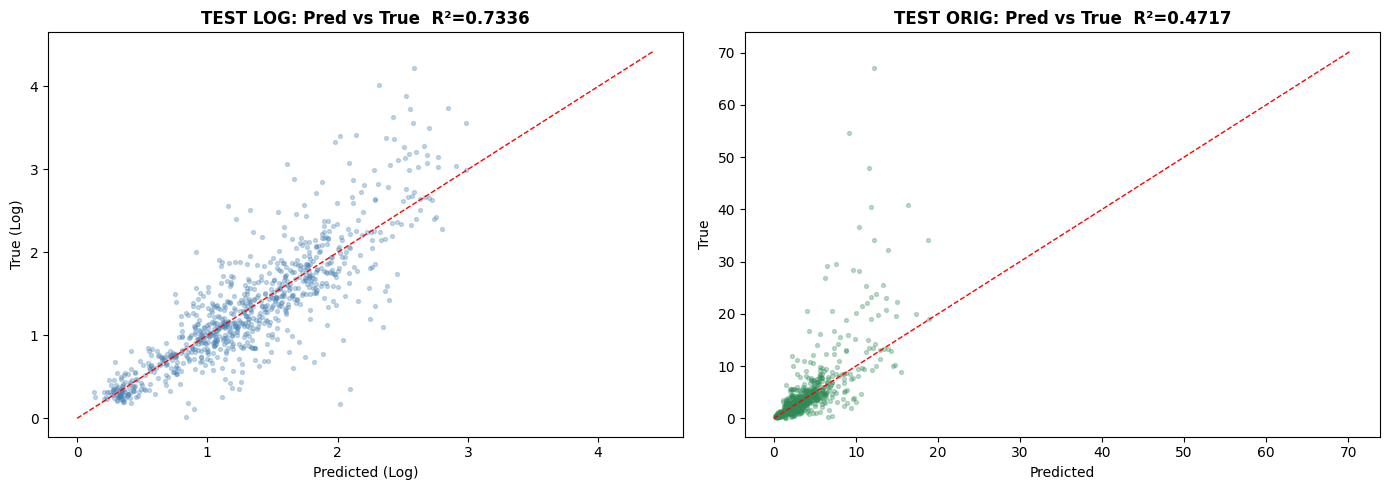

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_log, np.log1p(test_labels), alpha=0.3, s=8, color='steelblue')
lim_log = max(np.log1p(test_labels).max(), y_pred_log.max()) * 1.05
axes[0].plot([0,lim_log],[0,lim_log],'r--',lw=1)
axes[0].set_title(f'TEST LOG: Pred vs True  R²={m_test_log["R2"]:.4f}', fontweight='bold')
axes[0].set_xlabel('Predicted (Log)'); axes[0].set_ylabel('True (Log)')

axes[1].scatter(y_pred, test_labels.values, alpha=0.3, s=8, color='seagreen')
lim = max(test_labels.max(), y_pred.max()) * 1.05
axes[1].plot([0,lim],[0,lim],'r--',lw=1)
axes[1].set_title(f'TEST ORIG: Pred vs True  R²={m_test_orig["R2"]:.4f}', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

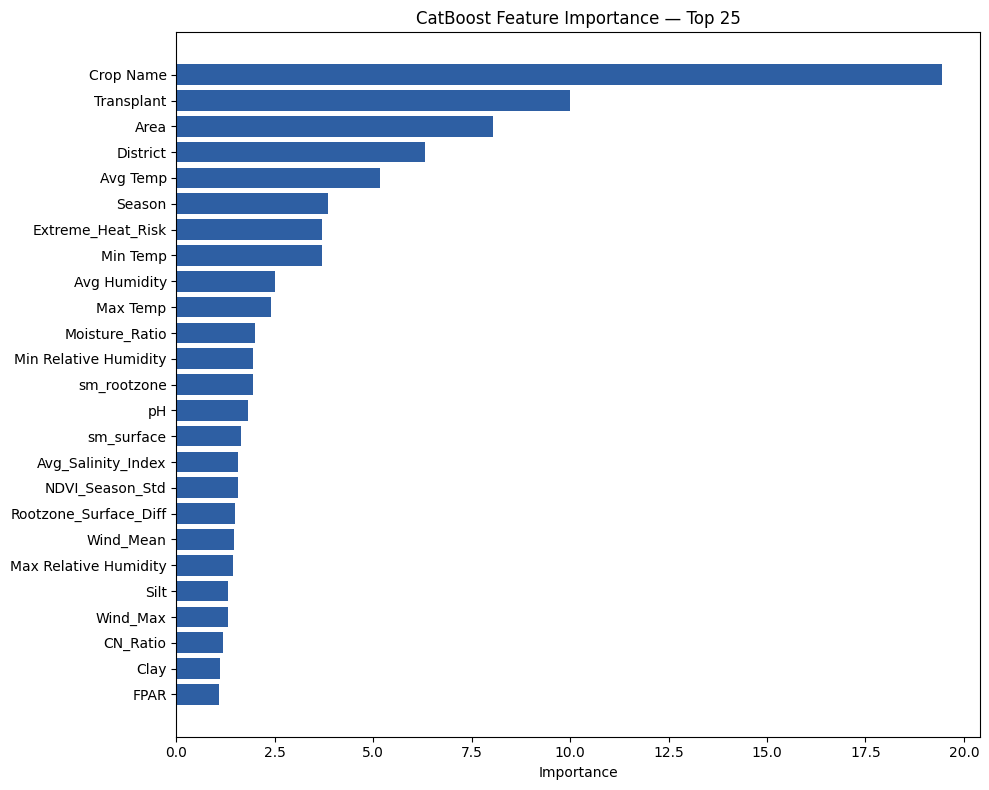

Top 10 features (CatBoost):
Crop Name            19.437995
Transplant           10.005112
Area                  8.031032
District              6.301041
Avg Temp              5.170378
Season                3.844820
Extreme_Heat_Risk     3.697423
Min Temp              3.685564
Avg Humidity          2.511447
Max Temp              2.405041


In [38]:
# Feature Importance
importances = pd.Series(
    model.get_feature_importance(),
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top25 = importances.head(25)
colors = ['#2E5FA3' for _ in top25.index]

ax.barh(top25.index[::-1], top25.values[::-1], color=colors[::-1])
ax.set_title('CatBoost Feature Importance — Top 25')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

print(f'Top 10 features (CatBoost):')
print(importances.head(10).to_string())